# Лабораторная работа №4
**Случайный лес, AdaBoost и градиентный бустинг. ROC-кривые**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_curve, auc)

df = pd.read_csv('processed_titanic.csv')
df[['Sex_male','Embarked_Q','Embarked_S']] = df[['Sex_male','Embarked_Q','Embarked_S']].astype(int)
print(df.shape)
df.head()

(891, 10)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.000000,0.0,1.0,0.271174,0.125,0.0,0.014151,1,0,1
1,0.001124,1.0,0.0,0.472229,0.125,0.0,0.139136,0,0,0
2,0.002247,1.0,1.0,0.321438,0.000,0.0,0.015469,0,0,1
3,0.003371,1.0,0.0,0.434531,0.125,0.0,0.103644,0,0,1
4,0.004494,0.0,1.0,0.434531,0.000,0.0,0.015713,1,0,1


## 2. Подготовка выборок
Целевой признак — **Survived**. Разделение 80/20 со стратификацией.

In [2]:
X = df.drop(columns=['Survived','PassengerId'])
y = df['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(712, 8) (179, 8)


## 3. Случайный лес (Random Forest) + OOB-оценка

In [ ]:
# из обуч.выборки с возвращением генерируется n подвыборок
# из случ с возвращением 37 % обьектов не попадают - OOB обьекты\
# на каждой подвыборке обучается отдельное дерево
# итог - голосование(клас.) усреднение - (регресии)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
 
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f'OOB score      = {rf.oob_score_:.4f}')
print(f'Test accuracy  = {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf))

OOB score      = 0.8230
Test accuracy  = 0.7933
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       110
           1       0.81      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



## 4. AdaBoost

In [4]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada  = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

print(f'Accuracy = {accuracy_score(y_test, y_pred_ada):.4f}')
print(classification_report(y_test, y_pred_ada))

Accuracy = 0.7989
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



## 5. Градиентный бустинг

In [ ]:

## Антиградиент функции потерь по предсказаниям - направление в котором нужно сдвинуть предсказание
## чтобы улучшить модель.Эти градиенты - псевдоостатки.Обучается новое дерево предсказывает эти псевдостатки
## предсказание дерева добавляется с текущим предсказаниям и шаги повторяются
## Градиентный спуск в пространстве функций(постенно спускаемся по поверхности ошибок и каждое новое
# дерево - шаг в сторону минимума)

In [5]:
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print(f'Accuracy = {accuracy_score(y_test, y_pred_gb):.4f}')
print(classification_report(y_test, y_pred_gb))

Accuracy = 0.8101
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



## 6. ROC-кривые для всех трёх моделей

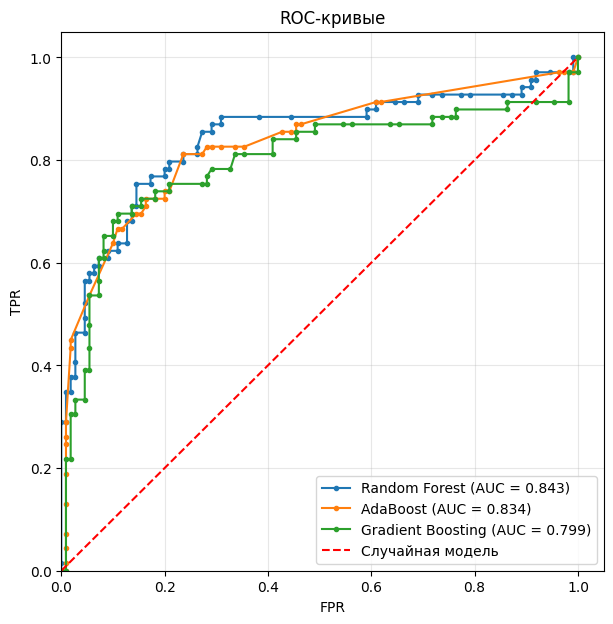

In [6]:
models = {
    'Random Forest'    : y_proba_rf,
    'AdaBoost'         : y_proba_ada,
    'Gradient Boosting': y_proba_gb,
}

plt.figure(figsize=(7,7))
for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, marker='.', label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'r--', label='Случайная модель')
plt.xlim([0,1.05]); plt.ylim([0,1.05])
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC-кривые')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 7. Сводная таблица метрик

In [7]:
def metrics(y_true, y_pred, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return accuracy_score(y_true, y_pred), auc(fpr, tpr)

rows = []
for name, (pred, proba) in {
    'Random Forest'    : (y_pred_rf,  y_proba_rf),
    'AdaBoost'         : (y_pred_ada, y_proba_ada),
    'Gradient Boosting': (y_pred_gb,  y_proba_gb),
}.items():
    acc, a = metrics(y_test, pred, proba)
    rows.append([name, round(acc,4), round(a,4)])

summary = pd.DataFrame(rows, columns=['Модель','Accuracy','ROC-AUC'])
summary

,Модель,Accuracy,ROC-AUC
0,Random Forest,0.7933,0.8428
1,AdaBoost,0.7989,0.8336
2,Gradient Boosting,0.8101,0.7986


## 8. Выводы

- **Random Forest** оценён через встроенную OOB-оценку (`oob_score_`), что позволяет судить о качестве без отдельной валидационной выборки. OOB-оценка близка к точности на тесте.
- **AdaBoost** и **Gradient Boosting** показывают сопоставимые результаты; градиентный бустинг обычно даёт немного более высокий ROC-AUC за счёт оптимизации градиентов функции потерь.
- Все три ансамблевые модели заметно превосходят случайное предсказание: ROC-кривые расположены значительно выше диагонали.
- Ансамбли деревьев в целом дают более устойчивый результат, чем одиночное дерево решений из лабораторной работы №3.